# 📌 Problem Statement


# 📦 Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📂 Load Dataset


In [2]:

df = pd.read_csv("../RawData/Titanic_Dataset.csv")

print(df.shape)


(891, 12)


# 🔍 Data Understanding


In [3]:

print(df.info())
print("\n--------------------------------------------------------------------------------\n")


print(df.describe().astype(int))
print("\n--------------------------------------------------------------------------------\n")

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--------------------------------------------------------------------------------

       PassengerId  Survived  Pclass  Age  SibSp  Parch  Fare
count          891       891     891  714    891    891   891
mean           446         0    

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 🧹 Data Cleaning


In [4]:
# missing Values 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
# drop Columns 
df.drop("Cabin" , axis = 1 , inplace = True ) 

# Drop ID column -- not hellp in preduction 
df.drop(["Name" , "PassengerId" , "Ticket"] , axis = 1 , inplace =True)

In [6]:
# Fill Missing value 

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df_copy = df.copy()



In [7]:
# convert SEX to binary - 0[MALE] 
df["Sex"] = df["Sex"].map({"male" : 0 , "female" : 1})


In [8]:
# Re-Check Null vaules 

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# ⚙️ Feature Engineering

In [9]:
# Family Size 

df["FamilySize"] = df["SibSp"] + df["Parch"]


In [10]:
# no Family Alone 

df["IsAlone"] = (df["FamilySize"] == 0).astype(int)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,S,1,0
1,1,1,1,38.0,1,0,71.2833,C,1,0
2,1,3,1,26.0,0,0,7.9250,S,0,1
3,1,1,1,35.0,1,0,53.1000,S,1,0
4,0,3,0,35.0,0,0,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,S,0,1
887,1,1,1,19.0,0,0,30.0000,S,0,1
888,0,3,1,28.0,1,2,23.4500,S,3,0
889,1,1,0,26.0,0,0,30.0000,C,0,1


In [11]:
# Drop SibSP & Parch

df.drop(["SibSp","Parch"] , axis = 1,inplace = True )
df

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,7.2500,S,1,0
1,1,1,1,38.0,71.2833,C,1,0
2,1,3,1,26.0,7.9250,S,0,1
3,1,1,1,35.0,53.1000,S,1,0
4,0,3,0,35.0,8.0500,S,0,1
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,13.0000,S,0,1
887,1,1,1,19.0,30.0000,S,0,1
888,0,3,1,28.0,23.4500,S,3,0
889,1,1,0,26.0,30.0000,C,0,1


In [12]:
# combine sex with Pclass --- value is 1 or closer to 1 hav ehigher chnace of survival as ( 1(female) * 1(1st class) = 1 (most survived))
df["Sex_Pclass"] = df["Sex"] * df["Pclass"]
df

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Sex_Pclass
0,0,3,0,22.0,7.2500,S,1,0,0
1,1,1,1,38.0,71.2833,C,1,0,1
2,1,3,1,26.0,7.9250,S,0,1,3
3,1,1,1,35.0,53.1000,S,1,0,1
4,0,3,0,35.0,8.0500,S,0,1,0
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,13.0000,S,0,1,0
887,1,1,1,19.0,30.0000,S,0,1,1
888,0,3,1,28.0,23.4500,S,3,0,3
889,1,1,0,26.0,30.0000,C,0,1,0


# 📊 Exploratory Data Analysis (EDA)


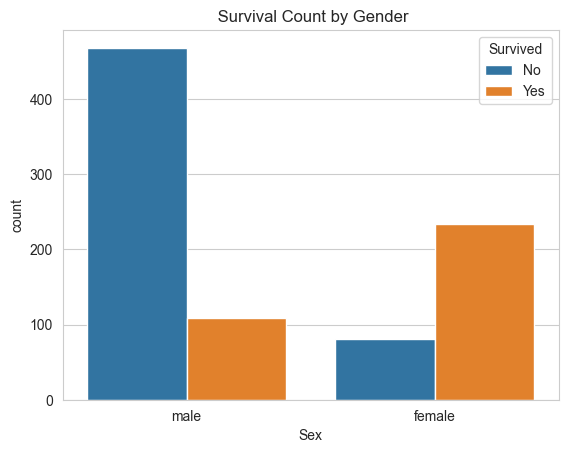


--------------------------------------------------------------------------------------------------------------------------------------



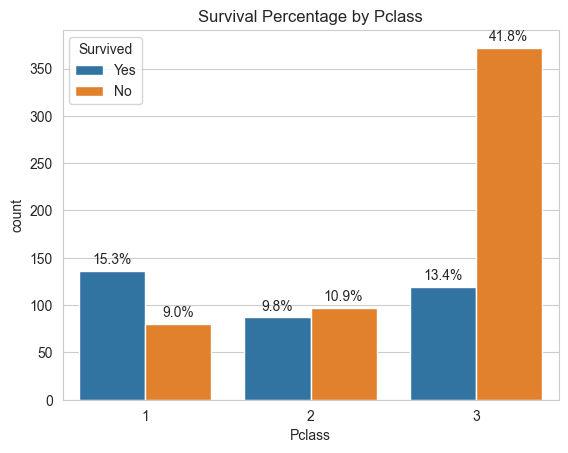


--------------------------------------------------------------------------------------------------------------------------------------



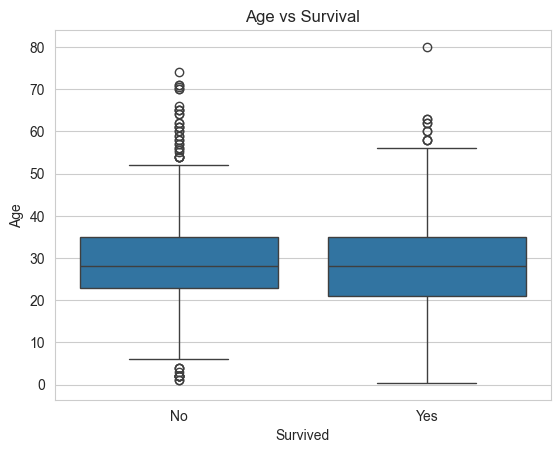

In [13]:
#  1-- Survival Count by Gender
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_copy["Survived"] = df_copy["Survived"].map({0 : "No" , 1 : "Yes"})  #Mapping in df_copy  not affact ML Models 

sns.countplot(x ="Sex" , hue ="Survived" , data=df_copy)
plt.title(" Survival Count by Gender")
plt.show()

print("\n--------------------------------------------------------------------------------------------------------------------------------------\n")



# 2-----Survival Count by Pclass

ax = sns.countplot(x="Pclass", hue="Survived", data=df_copy)

# total count
total = len(df_copy)

# add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{(v.get_height()/total)*100:.1f}%' for v in container],
        padding=3
    )

plt.title("Survival Percentage by Pclass")
plt.show()

print("\n--------------------------------------------------------------------------------------------------------------------------------------\n")


# 3---- Age Distribution by Survival

sns.boxplot(x="Survived", y="Age", data=df_copy)
plt.title("Age vs Survival")
plt.show()

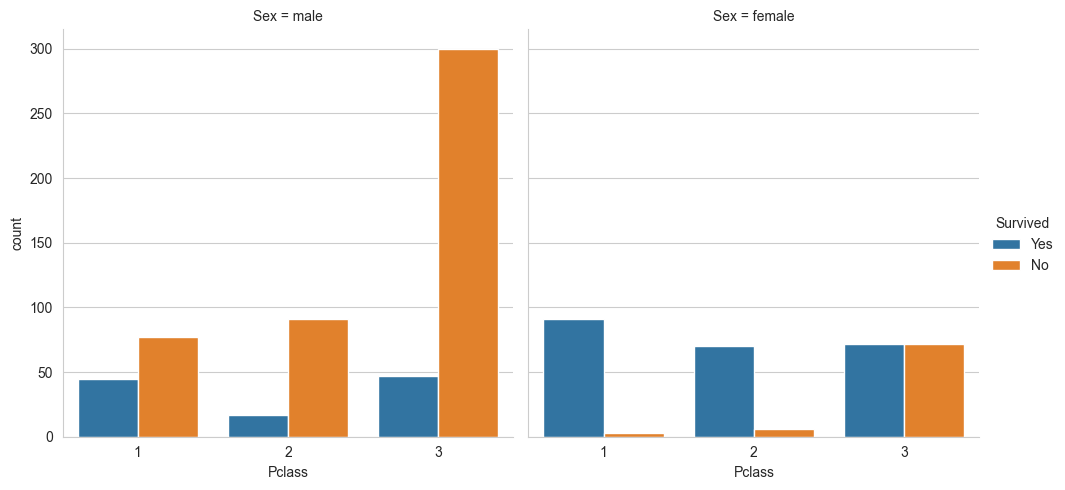

In [14]:
# Overall Survival based on SEX,Pclass,Age

sns.catplot(x="Pclass", hue="Survived", col="Sex", data=df_copy, kind="count")
plt.show()

# 🔄 Feature Selection


In [15]:
    # Select Feature 

x = df[["Pclass", "Sex", "Age", "FamilySize", "IsAlone", "Fare"]]
y = df["Survived"]

# ✂️ Train-Test Split


In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# 🤖 Model Building


In [17]:
# Import model 
from sklearn.linear_model import LogisticRegression

In [18]:
# Create Model 
model = LogisticRegression()

In [19]:
# Train Model
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
# MAke predictions

y_pred = model.predict(x_test)


In [21]:
# Check Accuracy 

from sklearn.metrics import accuracy_score # imported early at top

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7988826815642458


## Decision Tree

In [22]:
#imporrt model 
from sklearn.tree import DecisionTreeClassifier

#create Model 
# model1 = DecisionTreeClassifier(max_depth=5, min_samples_split=10)   #  Accuracy DTree :  0.7877094972067039
# model1 = DecisionTreeClassifier()                                    #  Accuracy DTre  : 0.776

model_Dtree = DecisionTreeClassifier(max_depth = 3)                         # Accuracy DTree :  0.8100558659217877            

# Model train 
model_Dtree.fit(x_train, y_train)

# predict Model 
y_pred1 = model_Dtree.predict(x_test)



In [23]:
# DecisionTree Model Evaluation 

accuracy_dTree = accuracy_score(y_test , y_pred1)

print("\n Accuracy DTree : " , accuracy_dTree)


 Accuracy DTree :  0.8156424581005587


## Random Forest

In [24]:
# Import Model 
from sklearn.ensemble import RandomForestClassifier

# Create Model
model_RForest = RandomForestClassifier(random_state=42)

# Train Model 
model_RForest.fit(x_train , y_train)


# Model Predict 
y_pred2 = model_RForest.predict(x_test)


In [25]:
# Random Forest  Model Evaluation 

accuracy_RF =accuracy_score(y_test , y_pred2)

print("Accuracy LRegression : " , accuracy)
print("\n Accuracy DTree : " , accuracy_dTree)
print("\n Accuracy Rforest : " , accuracy_RF)

Accuracy LRegression :  0.7988826815642458

 Accuracy DTree :  0.8156424581005587

 Accuracy Rforest :  0.7821229050279329


# 📊 Model Comparison

In [26]:

results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, accuracy_dTree, accuracy_RF]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.798883
1,Decision Tree,0.815642
2,Random Forest,0.782123


# 📈 Model Evaluation


# 🌳 Feature Importance


In [27]:
## Feature Importance 

import pandas as pd

feature_importance = pd.Series(model_RForest.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False)

Fare          0.307212
Sex           0.273009
Age           0.264423
Pclass        0.075140
FamilySize    0.065280
IsAlone       0.014936
dtype: float64

<Axes: title={'center': 'Feature Importance'}>

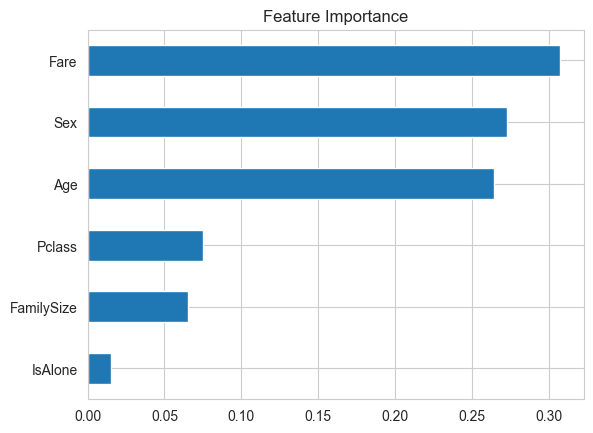

In [28]:
# Plot
import pandas as pd

# Get feature importance from trained Random Forest model
feature_importance = pd.Series(model_RForest.feature_importances_, index=x.columns)

# Sort values
feature_importance = feature_importance.sort_values()

# Plot
feature_importance.plot(kind='barh', title="Feature Importance")

# 🚀 Model Improvement using Feature Engineering


In [29]:
# Select Feature

x1 = df[["IsAlone" ,"Sex" ,"Age" ,"Pclass" ,"FamilySize" ,"Sex_Pclass", "Fare"]]


#Train-Test_SPlit

x_train , x_test, y_train , y_test = train_test_split(x1 , y , test_size =0.2)

#create Model 
model_LR_1 = LogisticRegression(max_iter=1000)

model_DT_1 = DecisionTreeClassifier(max_depth = 3)       

model_RF_1 = RandomForestClassifier(random_state=42)

#Train model 
model_LR_1.fit(x_train , y_train)

model_DT_1.fit(x_train , y_train)

model_RF_1.fit(x_train , y_train)



# make preduction 
y_pred_LR_1 = model_LR_1.predict(x_test)

y_pred_DT_1 = model_DT_1.predict(x_test)

y_pred_RF_1 = model_RF_1.predict(x_test)




In [30]:
# model accuracy 

accuracy_LR_1 = accuracy_score( y_test , y_pred_LR_1)
print("Accuracy_LR_Feature : " ,accuracy_LR_1)


accuracy_DT_1 = accuracy_score( y_test , y_pred_DT_1)
print("\n Accuracy_LR_Feature : " ,accuracy_DT_1)

accuracy_RF_1 = accuracy_score( y_test , y_pred_RF_1)
print("\n Accuracy_RF_Feature : " ,accuracy_RF_1)

Accuracy_LR_Feature :  0.8156424581005587

 Accuracy_LR_Feature :  0.8379888268156425

 Accuracy_RF_Feature :  0.8324022346368715


# 📊 Model Comparison

In [31]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_LR_1, accuracy_DT_1, accuracy_RF_1]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.815642
1,Decision Tree,0.837989
2,Random Forest,0.832402


# 🧾 Final Conclusion